# Лабораторная работа № 1 — Сети прямого распространения (MLP на MNIST)
Цель работы: изучить принципы построения, обучения, оптимизации и оценки качества нейронных сетей прямого распространения. Набор данных — MNIST (рукописные цифры).

Ноутбук покрывает все пункты задания: загрузка и подготовка данных, builder MLP с 1–2 скрытыми слоями, базовое обучение с валидацией, оценка на тесте, исследование dropout и batch_size, подбор гиперпараметров (GridSearchCV), сравнение 1 и 2 скрытых слоёв при равном бюджете параметров.

Базовая конфигурация: один скрытый слой (128 нейронов), dropout 0.2, batch_size 128; 20% обучающей выборки откладывается на валидацию.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print('tf', tf.__version__)
print('gpus:', tf.config.list_physical_devices('GPU'))

tf 2.21.0
gpus: []


## П.1 — Загрузка MNIST, примеры, нормализация, flatten

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


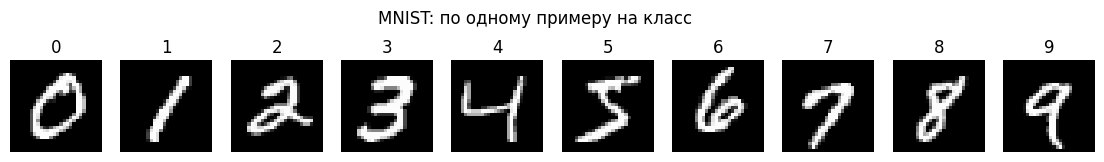

train (60000, 784) 0.0 1.0
test  (10000, 784) 0.0 1.0


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

# по 1 изображению на каждую цифру из обучающего набора
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for d in range(10):
    idx = np.flatnonzero(y_train_full == d)[0]
    axes[d].imshow(x_train_full[idx], cmap='gray')
    axes[d].set_title(str(d)); axes[d].axis('off')
plt.suptitle('MNIST: по одному примеру на класс'); plt.show()

# нормализация + flatten в вектор 784
x_train_full = (x_train_full.astype('float32') / 255.0).reshape(-1, 28 * 28)
x_test = (x_test.astype('float32') / 255.0).reshape(-1, 28 * 28)
print('train', x_train_full.shape, x_train_full.min(), x_train_full.max())
print('test ', x_test.shape, x_test.min(), x_test.max())

## П.2 — Builder MLP: 1–2 скрытых слоя, dropout опционально

In [3]:
def build_mlp(hidden=(128,), dropout=0.2, input_dim=28 * 28, n_classes=10):
    """hidden: tuple, напр. (128,) или (128, 64). dropout применяется после каждого скрытого слоя."""
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for h in hidden:
        model.add(layers.Dense(h, activation='relu'))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(n_classes, activation='softmax'))
    model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                    optimizer='adam', metrics=['acc'])
    return model

def count_params(hidden, input_dim=28 * 28, n_classes=10):
    """Аналитический подсчёт: сумма (fan_in+1)*fan_out по всем Dense-слоям."""
    dims = [input_dim, *hidden, n_classes]
    return sum((a + 1) * b for a, b in zip(dims[:-1], dims[1:]))

m = build_mlp((128,), 0.2)
m.summary()
print('analytic:', count_params((128,)), '| keras:', m.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

analytic: 101770 | keras: 101770


## П.3 — Базовое обучение 15–20 эпох, кривые, summary

Epoch 1/15
375/375 - 2s - 5ms/step - acc: 0.8721 - loss: 0.4493 - val_acc: 0.9408 - val_loss: 0.2130
Epoch 2/15
375/375 - 1s - 3ms/step - acc: 0.9383 - loss: 0.2128 - val_acc: 0.9567 - val_loss: 0.1533
Epoch 3/15
375/375 - 1s - 3ms/step - acc: 0.9538 - loss: 0.1614 - val_acc: 0.9635 - val_loss: 0.1267
Epoch 4/15
375/375 - 1s - 3ms/step - acc: 0.9607 - loss: 0.1312 - val_acc: 0.9673 - val_loss: 0.1115
Epoch 5/15
375/375 - 1s - 3ms/step - acc: 0.9671 - loss: 0.1113 - val_acc: 0.9705 - val_loss: 0.1020
Epoch 6/15
375/375 - 1s - 3ms/step - acc: 0.9715 - loss: 0.0960 - val_acc: 0.9721 - val_loss: 0.0955
Epoch 7/15
375/375 - 1s - 3ms/step - acc: 0.9742 - loss: 0.0851 - val_acc: 0.9741 - val_loss: 0.0879
Epoch 8/15
375/375 - 1s - 2ms/step - acc: 0.9773 - loss: 0.0742 - val_acc: 0.9750 - val_loss: 0.0849
Epoch 9/15
375/375 - 1s - 2ms/step - acc: 0.9791 - loss: 0.0677 - val_acc: 0.9759 - val_loss: 0.0847
Epoch 10/15
375/375 - 1s - 2ms/step - acc: 0.9818 - loss: 0.0607 - val_acc: 0.9763 - val_lo

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

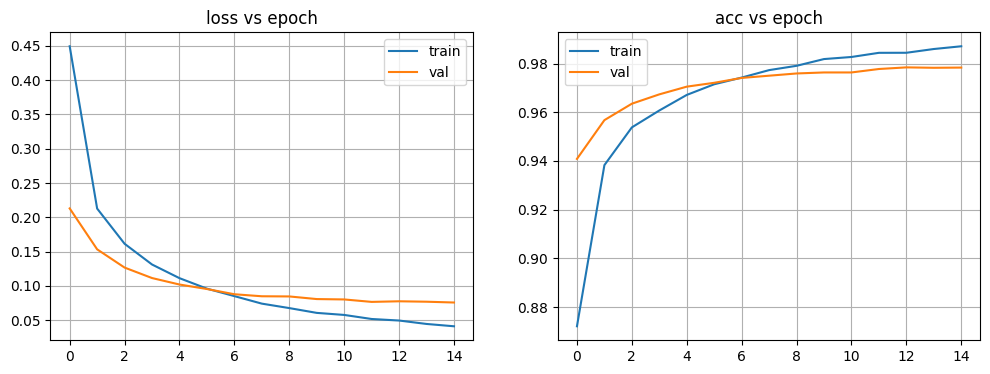

In [4]:
EPOCHS, BATCH = 15, 128
baseline = build_mlp(hidden=(128,), dropout=0.2)
hist = baseline.fit(x_train_full, y_train_full, epochs=EPOCHS, batch_size=BATCH,
                      validation_split=0.2, verbose=2)
baseline.summary()  # структура + число обучаемых параметров

assert baseline.count_params() == count_params((128,)) == 101770

h = hist.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('loss vs epoch'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(h['acc'], label='train'); ax[1].plot(h['val_acc'], label='val')
ax[1].set_title('acc vs epoch'); ax[1].legend(); ax[1].grid(True)
plt.show()

## П.4 — Тест: evaluate, confusion matrix, неверные примеры

evaluate: loss=0.0728 acc=0.9792
acc по confusion matrix: 0.9792 (evaluate дал 0.9792, разница=5.53e-09)
confusion matrix:
 [[ 972    1    0    1    0    1    2    1    2    0]
 [   0 1126    3    1    0    0    2    0    3    0]
 [   6    1 1010    2    1    0    2    7    3    0]
 [   0    0    5  995    0    2    0    4    2    2]
 [   1    0    1    0  964    0    6    1    2    7]
 [   3    0    0    8    1  866    7    2    4    1]
 [   6    3    1    0    1    3  942    0    2    0]
 [   1    4   11    5    0    0    0 1001    1    5]
 [   4    1    2    9    2    3    2    4  943    4]
 [   3    4    0    7    9    0    1    6    6  973]]


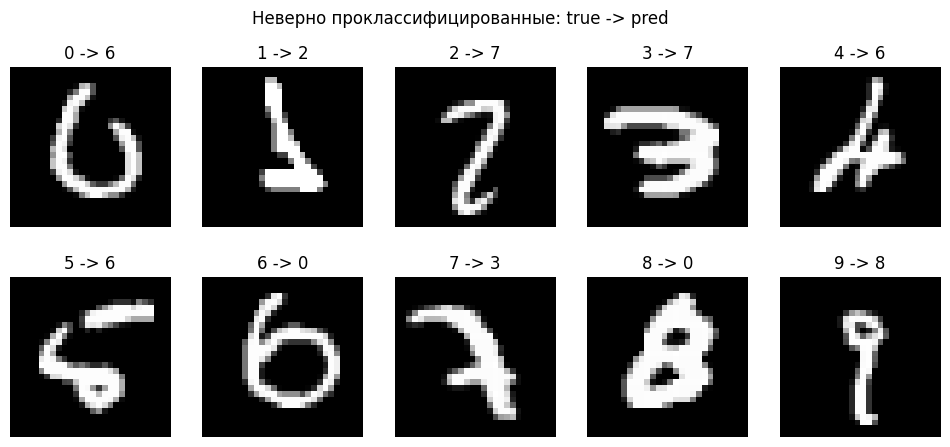

In [ ]:
loss, acc = baseline.evaluate(x_test, y_test, verbose=0)
print(f'evaluate: loss={loss:.4f} acc={acc:.4f}')

pred = np.argmax(baseline.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, pred)
acc_cm = np.trace(cm) / np.sum(cm)
print(f'acc по confusion matrix: {acc_cm:.4f} (evaluate дал {acc:.4f}, разница={abs(acc - acc_cm):.2e})')
print('confusion matrix:\n', cm)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Неверно проклассифицированные: true -> pred')
for t in range(10):
    ax = axes.flat[t]
    ax.axis('off')
    bad = np.flatnonzero((y_test == t) & (pred != y_test))
    if len(bad) == 0:
        ax.set_title(f'{t}: ошибок нет')
        continue
    i = bad[0]
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'{t} -> {int(pred[i])}')
plt.show()

## П.5а — Влияние dropout (0, 0.1, 0.2, 0.3) при фиксированном batch_size=128


dropout=0.0: train_loss=0.0151 val_loss=0.0961 train_acc=0.9979 val_acc=0.9738
dropout=0.1: train_loss=0.0295 val_loss=0.0838 train_acc=0.9913 val_acc=0.9770
dropout=0.2: train_loss=0.0424 val_loss=0.0758 train_acc=0.9863 val_acc=0.9780
dropout=0.3: train_loss=0.0584 val_loss=0.0814 train_acc=0.9822 val_acc=0.9758


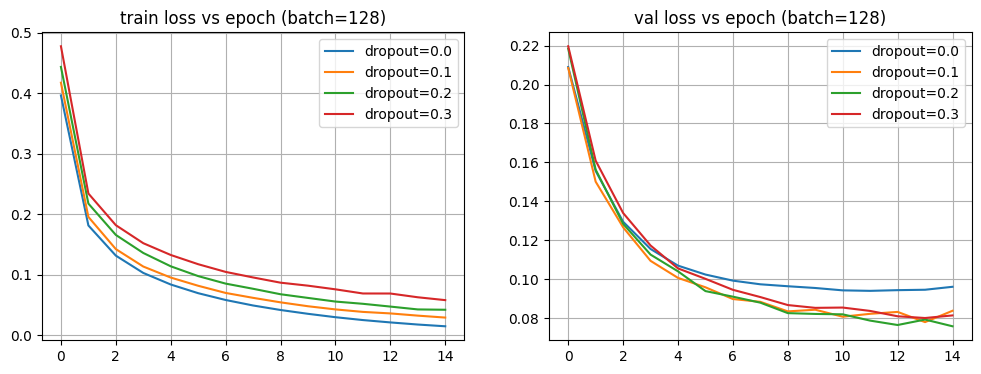

In [6]:
SWEEP_EPOCHS = 15
drop_vals = [0.0, 0.1, 0.2, 0.3]
drop_hist = {}
for d in drop_vals:
    tf.keras.backend.clear_session(); np.random.seed(SEED); tf.random.set_seed(SEED)
    mdl = build_mlp(hidden=(128,), dropout=d)
    hh = mdl.fit(x_train_full, y_train_full, epochs=SWEEP_EPOCHS, batch_size=128,
                 validation_split=0.2, verbose=0)
    drop_hist[d] = hh.history
    print(f'dropout={d}: train_loss={hh.history["loss"][-1]:.4f} val_loss={hh.history["val_loss"][-1]:.4f} '
          f'train_acc={hh.history["acc"][-1]:.4f} val_acc={hh.history["val_acc"][-1]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for d in drop_vals:
    ax[0].plot(drop_hist[d]['loss'], label=f'dropout={d}')
    ax[1].plot(drop_hist[d]['val_loss'], label=f'dropout={d}')
ax[0].set_title('train loss vs epoch (batch=128)'); ax[0].legend(); ax[0].grid(True)
ax[1].set_title('val loss vs epoch (batch=128)'); ax[1].legend(); ax[1].grid(True)
plt.show()

## П.5б — Влияние batch_size (16, 32, 64, 128) при фиксированном dropout=0.2

batch=16: train_loss=0.0306 val_loss=0.1006 train_acc=0.9896 val_acc=0.9763
batch=32: train_loss=0.0305 val_loss=0.0858 train_acc=0.9896 val_acc=0.9789
batch=64: train_loss=0.0337 val_loss=0.0845 train_acc=0.9890 val_acc=0.9785
batch=128: train_loss=0.0418 val_loss=0.0775 train_acc=0.9872 val_acc=0.9776


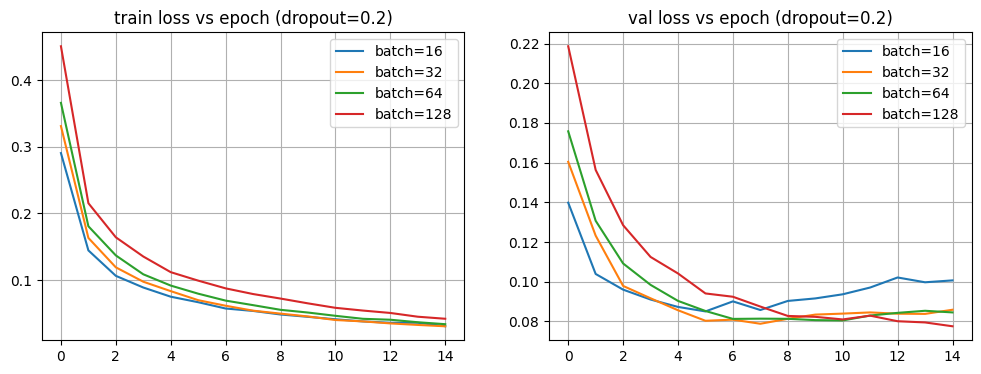

In [7]:
bs_vals = [16, 32, 64, 128]
bs_hist = {}
for bs in bs_vals:
    tf.keras.backend.clear_session(); np.random.seed(SEED); tf.random.set_seed(SEED)
    mdl = build_mlp(hidden=(128,), dropout=0.2)
    hh = mdl.fit(x_train_full, y_train_full, epochs=SWEEP_EPOCHS, batch_size=bs,
                 validation_split=0.2, verbose=0)
    bs_hist[bs] = hh.history
    print(f'batch={bs}: train_loss={hh.history["loss"][-1]:.4f} val_loss={hh.history["val_loss"][-1]:.4f} '
          f'train_acc={hh.history["acc"][-1]:.4f} val_acc={hh.history["val_acc"][-1]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for bs in bs_vals:
    ax[0].plot(bs_hist[bs]['loss'], label=f'batch={bs}')
    ax[1].plot(bs_hist[bs]['val_loss'], label=f'batch={bs}')
ax[0].set_title('train loss vs epoch (dropout=0.2)'); ax[0].legend(); ax[0].grid(True)
ax[1].set_title('val loss vs epoch (dropout=0.2)'); ax[1].legend(); ax[1].grid(True)
plt.show()

## П.6 — GridSearchCV: число нейронов × batch_size, один скрытый слой
Подбор гиперпараметров по сетке: число нейронов скрытого слоя (64/128/256) × batch_size (32/64/128), кросс-валидация (cv=3) на обучающей выборке. Остальные параметры фиксированы: dropout 0.2, 10 эпох.

In [8]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def _mlp_model(hidden=(128,), dropout=0.2):
    return build_mlp(hidden, dropout)

def make_clf(epochs=10, batch_size=128):
    return KerasClassifier(model=_mlp_model,
                           loss=keras.losses.SparseCategoricalCrossentropy(),
                           optimizer='adam', metrics=['acc'],
                           epochs=epochs, batch_size=batch_size, verbose=0)

grid = GridSearchCV(make_clf(),
                    param_grid={'model__hidden': [(64,), (128,), (256,)],
                                'batch_size': [32, 64, 128]},
                    cv=3, n_jobs=1, verbose=1)
grid.fit(x_train_full, y_train_full)
print('best:', grid.best_params_, 'score=%.4f' % grid.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
best: {'batch_size': 32, 'model__hidden': (256,)} score=0.9764


## П.7 — Аналитика параметров + 1 vs 2 слоя при равном бюджете
$$P_{1}(h) = (784+1)h + (h+1)\cdot 10 = 795h + 10$$
$$P_{2}(h_1,h_2) = (784+1)h_1 + (h_1+1)h_2 + (h_2+1)\cdot 10 = 785h_1 + h_1h_2 + 11h_2 + 10$$
Dropout параметров не добавляет. Берём: 1 слой $h=100$ → $P=79\,510$; 2 слоя $(96,64)$ → $P=82\,218$ — оба в диапазоне 70–100k и отличаются <4%.

1 слой (100,):    P=79510
2 слоя (96, 64):  P=82218  (разница=+3.4%)
1x100: P=79510 test_loss=0.0762 test_acc=0.9756
2x96x64: P=82218 test_loss=0.0872 test_acc=0.9770


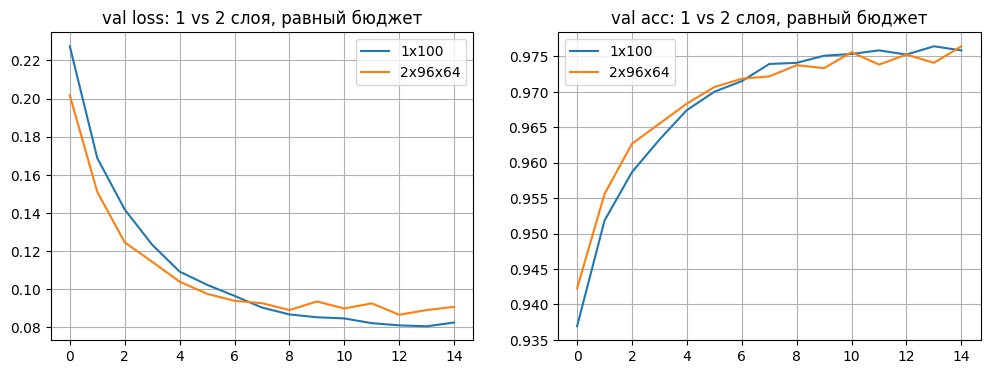

In [9]:
P1 = count_params((100,)); P2 = count_params((96, 64))
print(f'1 слой (100,):    P={P1}')
print(f'2 слоя (96, 64):  P={P2}  (разница={(P2 - P1) / P1:+.1%})')
assert 70_000 <= P1 <= 100_000 and 70_000 <= P2 <= 100_000

res = {}
for name, hid in [('1x100', (100,)), ('2x96x64', (96, 64))]:
    tf.keras.backend.clear_session(); np.random.seed(SEED); tf.random.set_seed(SEED)
    mdl = build_mlp(hidden=hid, dropout=0.2)
    hh = mdl.fit(x_train_full, y_train_full, epochs=15, batch_size=128,
                 validation_split=0.2, verbose=0)
    lt, at = mdl.evaluate(x_test, y_test, verbose=0)
    res[name] = (hh.history, lt, at)
    print(f'{name}: P={mdl.count_params()} test_loss={lt:.4f} test_acc={at:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, (hh, _, _) in res.items():
    ax[0].plot(hh['val_loss'], label=name)
    ax[1].plot(hh['val_acc'], label=name)
ax[0].set_title('val loss: 1 vs 2 слоя, равный бюджет'); ax[0].legend(); ax[0].grid(True)
ax[1].set_title('val acc: 1 vs 2 слоя, равный бюджет'); ax[1].legend(); ax[1].grid(True)
plt.show()
(_, l1, a1), (_, l2, a2) = res['1x100'], res['2x96x64']